<a href="https://colab.research.google.com/github/Nixita12/ClimateGuardian/blob/main/ClimateGuardian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Title:** ClimateGuardian AI – Climate Change Prediction and Analysis System

**Project Description:**
ClimateGuardian AI is an artificial intelligence-based system developed to support **SDG 13: Climate Action** by analyzing historical climate data and human activity indicators to understand and predict the impact of climate change. The system uses machine learning techniques to analyze environmental factors such as CO₂ emissions, methane emissions, nitrous oxide levels, energy consumption, population, and GDP to identify the major contributors to climate pollution.

The model predicts future pollution trends and climate risks for upcoming years, helping to estimate potential environmental impacts. It also analyzes which human activities contribute most to pollution and provides data-driven insights that can support policymakers and environmental organizations in developing effective climate mitigation strategies. The system further generates automated policy recommendations based on pollution levels and environmental indicators to encourage sustainable practices and reduce climate change risks.


In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn torch transformers plotly shap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

import plotly.express as px

In [3]:
temp_url = "https://raw.githubusercontent.com/datasets/global-temp/master/data/annual.csv"
co2_url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"

temp = pd.read_csv(temp_url)
co2 = pd.read_csv(co2_url)

co2 = co2[[
    "year",
    "co2",
    "methane",
    "nitrous_oxide",
    "energy_per_capita",
    "population",
    "gdp"
]]

co2 = co2.groupby("year").mean().reset_index()

data = pd.merge(temp, co2, left_on="Year", right_on="year")

data = data.dropna()

data.head()

,Source,Year,Mean,year,co2,methane,nitrous_oxide,energy_per_capita,population,gdp
200,GISTEMP,1965,-0.1067,1965,346.275987,127.249229,36.534250,22126.584052,5.984135e+07,1.096509e+11
201,gcag,1965,-0.2044,1965,346.275987,127.249229,36.534250,22126.584052,5.984135e+07,1.096509e+11
202,GISTEMP,1966,-0.0575,1966,362.518858,131.598839,38.099977,22609.386506,6.106778e+07,1.154955e+11
203,gcag,1966,-0.1489,1966,362.518858,131.598839,38.099977,22609.386506,6.106778e+07,1.154955e+11
204,GISTEMP,1967,-0.0242,1967,373.776147,133.047381,39.529250,23424.006143,6.229093e+07,1.200269e+11


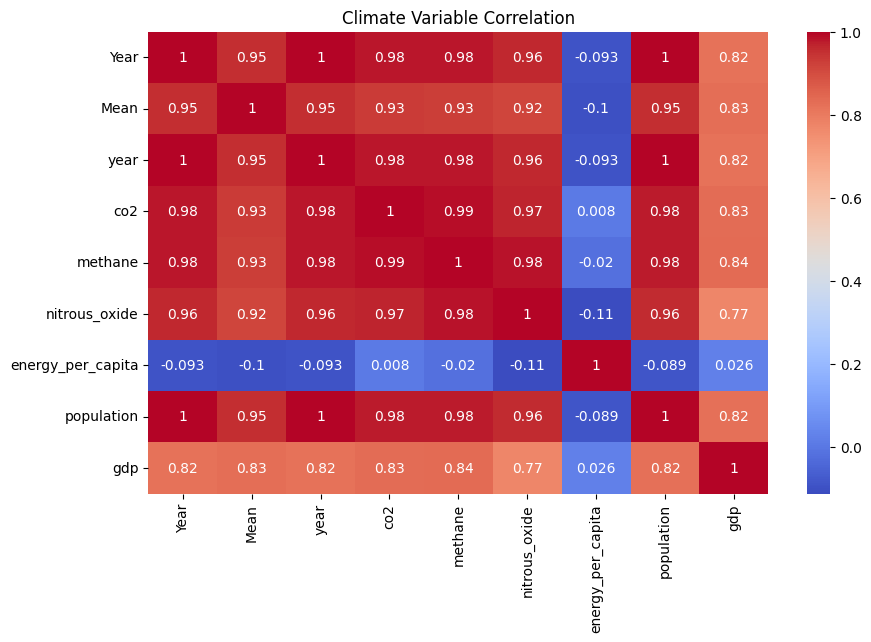

In [22]:
plt.figure(figsize=(10,6))

# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

sns.heatmap(numeric_data.corr(), cmap="coolwarm", annot=True)

plt.title("Climate Variable Correlation")
plt.show()

In [5]:
features = [
    "co2",
    "methane",
    "nitrous_oxide",
    "energy_per_capita",
    "population",
    "gdp"
]

target = "Mean"

scaler = MinMaxScaler()

scaled = scaler.fit_transform(data[features + [target]])

In [6]:
def create_sequences(data, seq_len=10):

    X = []
    y = []

    for i in range(len(data)-seq_len):

        X.append(data[i:i+seq_len,:-1])
        y.append(data[i+seq_len,-1])

    return np.array(X), np.array(y)

X, y = create_sequences(scaled)

In [8]:
class ClimateModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=6,
            hidden_size=64,
            batch_first=True
        )

        self.attention = nn.MultiheadAttention(
            embed_dim=64,
            num_heads=4
        )

        self.fc = nn.Linear(64,1)

    def forward(self,x):

        lstm_out,_ = self.lstm(x)

        lstm_out = lstm_out.permute(1,0,2)

        attn_out,_ = self.attention(
            lstm_out,
            lstm_out,
            lstm_out
        )

        out = self.fc(attn_out[-1])

        return out

In [9]:
model = ClimateModel()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

X_tensor = torch.tensor(X).float()
y_tensor = torch.tensor(y).float()

for epoch in range(200):

    optimizer.zero_grad()

    output = model(X_tensor)

    loss = criterion(output, y_tensor)

    loss.backward()

    optimizer.step()

    if epoch % 20 == 0:
        print("Epoch:",epoch,"Loss:",loss.item())

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([106])) that is different to the input size (torch.Size([106, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch: 0 Loss: 0.38842272758483887
Epoch: 20 Loss: 0.06852566450834274
Epoch: 40 Loss: 0.06694263964891434
Epoch: 60 Loss: 0.06379438191652298
Epoch: 80 Loss: 0.06358922272920609
Epoch: 100 Loss: 0.0635254979133606
Epoch: 120 Loss: 0.06348942220211029
Epoch: 140 Loss: 0.06346514075994492
Epoch: 160 Loss: 0.06344825029373169
Epoch: 180 Loss: 0.06343602389097214


In [10]:
future = X_tensor[-1].unsqueeze(0)

prediction = model(future)

print("Future Temperature Change:", prediction.item())

Future Temperature Change: 0.49230024218559265


In [11]:
def risk_score(temp):

    if temp > 2:
        return "EXTREME RISK"

    elif temp > 1.5:
        return "HIGH RISK"

    elif temp > 1:
        return "MODERATE RISK"

    else:
        return "LOW RISK"

print(risk_score(prediction.item()))

LOW RISK


In [12]:
risk = pd.DataFrame({

    "country":[
        "India",
        "USA",
        "China",
        "Brazil",
        "Germany"
    ],

    "risk":[0.8,0.6,0.7,0.5,0.4]

})

fig = px.choropleth(
    risk,
    locations="country",
    locationmode="country names",
    color="risk",
    title="Global Climate Risk Map"
)

fig.show()

In [13]:
from transformers import pipeline

policy_ai = pipeline(
    "text-generation",
    model="gpt2"
)

def generate_policy(temp):

    prompt = f"""
    Global temperature increase is {temp}°C.
    Suggest climate mitigation strategies for governments.
    """

    result = policy_ai(
        prompt,
        max_length=120
    )

    return result[0]["generated_text"]

print(generate_policy(prediction.item()))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=120) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



    Global temperature increase is 0.49230024218559265°C.
    Suggest climate mitigation strategies for governments.
                                                                                                                                                                                                                                                                    


In [15]:
X_np = X_tensor.detach().numpy()

In [16]:
def predict_fn(data):

    data_tensor = torch.tensor(data).float()

    with torch.no_grad():
        output = model(data_tensor)

    return output.detach().numpy()

In [17]:
import shap

background = X_np[:100]

explainer = shap.Explainer(predict_fn, background)

  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_344/3082176129.py:30: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



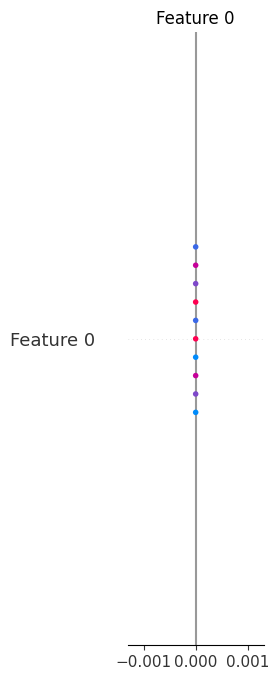

In [21]:
import shap

X_np = X_tensor.detach().numpy()

seq_len = X_np.shape[1]
n_features = X_np.shape[2]

X_flat = X_np.reshape(X_np.shape[0], seq_len * n_features)

def predict_fn(data):

    data = data.reshape(data.shape[0], seq_len, n_features)

    data_tensor = torch.tensor(data).float()

    with torch.no_grad():
        preds = model(data_tensor)

    return preds.detach().numpy()

background = X_flat[:50]

explainer = shap.KernelExplainer(
    predict_fn,
    background
)

shap_values = explainer.shap_values(X_flat[:10])

shap.summary_plot(
    shap_values,
    X_flat[:10]
)

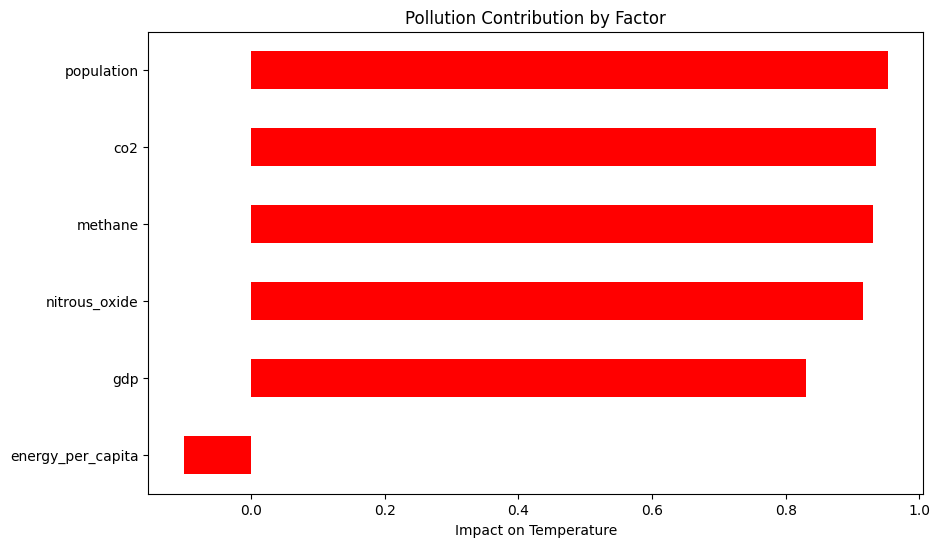

In [23]:
plt.figure(figsize=(10,6))

features = [
    "co2",
    "methane",
    "nitrous_oxide",
    "energy_per_capita",
    "population",
    "gdp"
]

target = "Mean"

importance = data[features].corrwith(data[target])

importance.sort_values().plot(
    kind="barh",
    color="red"
)

plt.title("Pollution Contribution by Factor")
plt.xlabel("Impact on Temperature")
plt.show()

In [25]:
print(co2.columns)

Index(['year', 'co2', 'methane', 'nitrous_oxide', 'energy_per_capita',
       'population', 'gdp'],
      dtype='object')


In [26]:
co2_url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"

co2 = pd.read_csv(co2_url)

print(co2.columns)

Index(['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2',
       'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct',
       'co2_including_luc', 'co2_including_luc_growth_abs',
       'co2_including_luc_growth_prct', 'co2_including_luc_per_capita',
       'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy',
       'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2',
       'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita',
       'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2',
       'cumulative_co2_including_luc', 'cumulative_coal_co2',
       'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2',
       'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita',
       'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2',
       'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita',
       'land_use_change_co2', 'land_use_chang

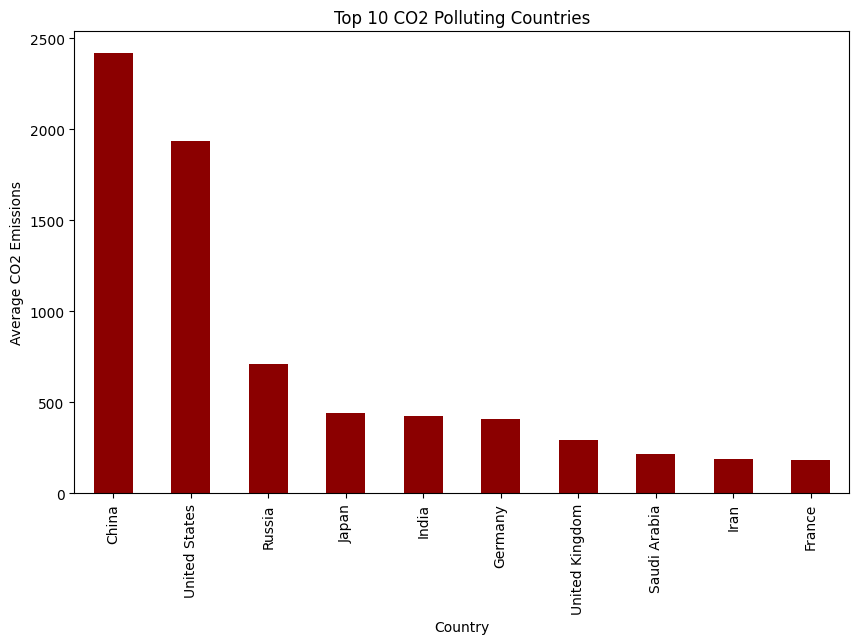

In [27]:
country_pollution = (
    co2[co2["iso_code"].notna()]      # remove continents like Asia, World
    .groupby("country")["co2"]
    .mean()
    .sort_values(ascending=False)
)

top_polluters = country_pollution.head(10)

plt.figure(figsize=(10,6))

top_polluters.plot(kind="bar", color="darkred")

plt.title("Top 10 CO2 Polluting Countries")
plt.ylabel("Average CO2 Emissions")
plt.xlabel("Country")

plt.show()

In [28]:
import plotly.express as px

map_data = co2.groupby("country")["co2"].mean().reset_index()

fig = px.choropleth(
    map_data,
    locations="country",
    locationmode="country names",
    color="co2",
    title="Global CO2 Pollution Map"
)

fig.show()

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np

features = [
    "methane",
    "nitrous_oxide",
    "energy_per_capita",
    "population",
    "gdp"
]

target = "co2"

df = co2[features + ["year", target]].dropna()

X = df[features + ["year"]]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
model_pollution = LinearRegression()

model_pollution.fit(X_train, y_train)

pred = model_pollution.predict(X_test)

In [31]:
future_years = np.arange(2030,2051)

future_data = pd.DataFrame({
    "year":future_years,
    "methane":df["methane"].mean(),
    "nitrous_oxide":df["nitrous_oxide"].mean(),
    "energy_per_capita":df["energy_per_capita"].mean(),
    "population":df["population"].mean(),
    "gdp":df["gdp"].mean()
})

future_predictions = model_pollution.predict(
    future_data[features + ["year"]]
)

future_data["predicted_co2"] = future_predictions

future_data.head()

,year,methane,nitrous_oxide,energy_per_capita,population,gdp,predicted_co2
0,2030,64.90009,20.088405,25096.925433,5.148887e+07,5.797082e+11,206.632272
1,2031,64.90009,20.088405,25096.925433,5.148887e+07,5.797082e+11,206.240542
2,2032,64.90009,20.088405,25096.925433,5.148887e+07,5.797082e+11,205.848812
3,2033,64.90009,20.088405,25096.925433,5.148887e+07,5.797082e+11,205.457082
4,2034,64.90009,20.088405,25096.925433,5.148887e+07,5.797082e+11,205.065353


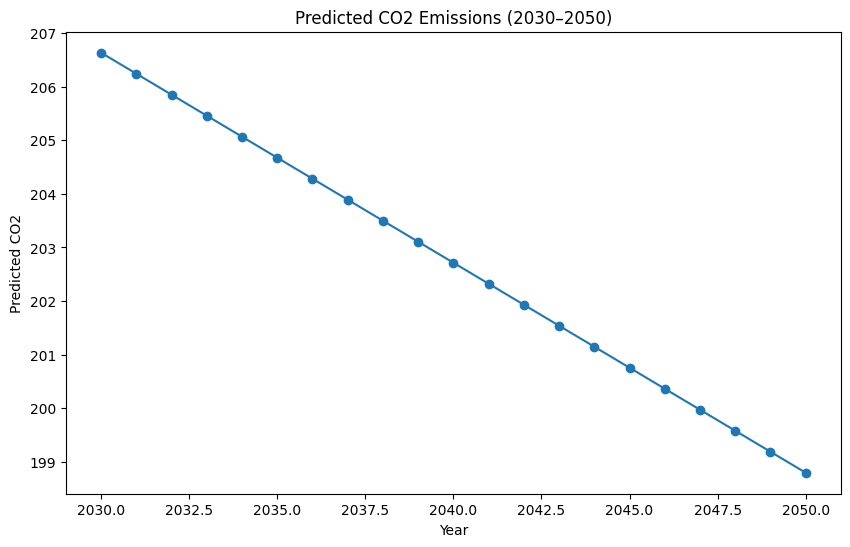

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    future_data["year"],
    future_data["predicted_co2"],
    marker="o"
)

plt.title("Predicted CO2 Emissions (2030–2050)")
plt.xlabel("Year")
plt.ylabel("Predicted CO2")

plt.show()

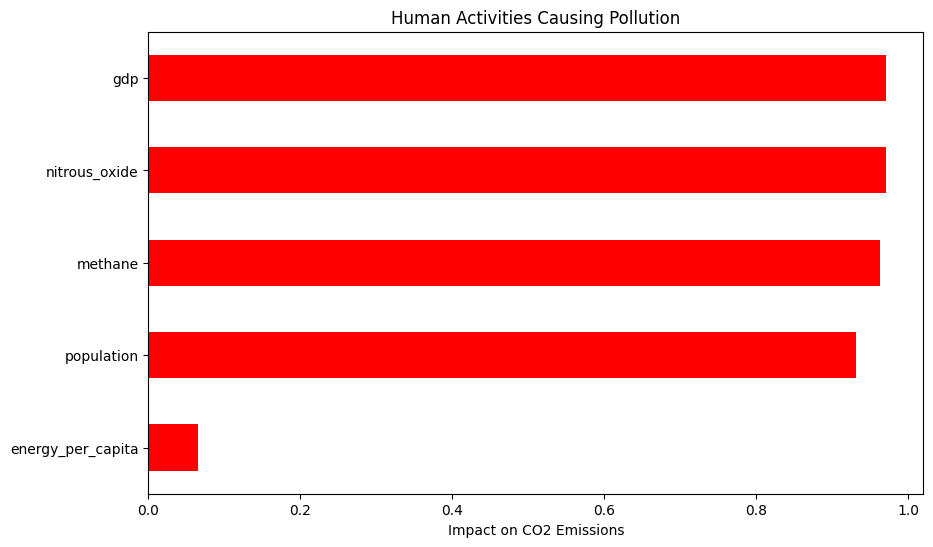

In [33]:
pollution_factors = df[features].corrwith(df["co2"])

pollution_factors.sort_values().plot(
    kind="barh",
    figsize=(10,6),
    color="red"
)

plt.title("Human Activities Causing Pollution")
plt.xlabel("Impact on CO2 Emissions")

plt.show()

In [34]:
def generate_policy(co2, methane, energy):

    policies = []

    if co2 > df["co2"].mean():
        policies.append(
            "Implement carbon tax and reduce fossil fuel use"
        )

    if methane > df["methane"].mean():
        policies.append(
            "Improve agricultural methane management"
        )

    if energy > df["energy_per_capita"].mean():
        policies.append(
            "Increase renewable energy adoption"
        )

    if len(policies) == 0:
        policies.append(
            "Maintain sustainable environmental policies"
        )

    return policies

ex

In [35]:
generate_policy(
    co2=12,
    methane=3,
    energy=50000
)

['Increase renewable energy adoption']

In [36]:
def climate_risk(predicted_co2):

    if predicted_co2 > 15:
        return "EXTREME RISK"

    elif predicted_co2 > 10:
        return "HIGH RISK"

    elif predicted_co2 > 5:
        return "MODERATE RISK"

    else:
        return "LOW RISK"

example

In [37]:
climate_risk(12)

'HIGH RISK'